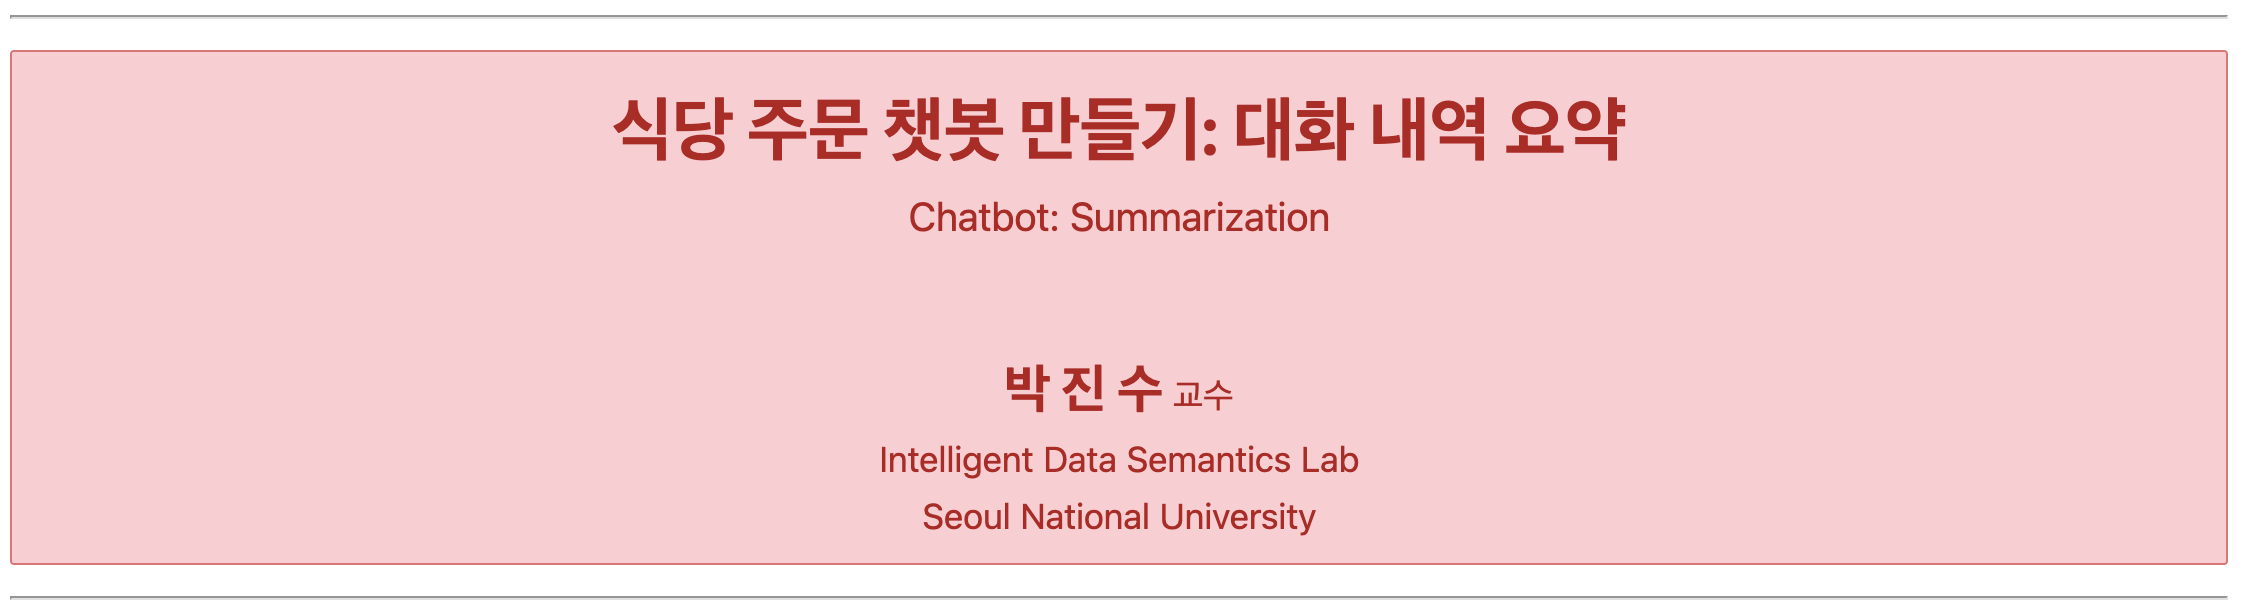

- - -    

- 본 자료는 강의를 위한 목적으로 제작되었습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#메뉴-도구" data-toc-modified-id="메뉴-도구-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>메뉴 도구</a></span></li><li><span><a href="#Greetings---인사말-메시지" data-toc-modified-id="Greetings---인사말-메시지-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Greetings - 인사말 메시지</a></span></li><li><span><a href="#시스템-프롬프트" data-toc-modified-id="시스템-프롬프트-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>시스템 프롬프트</a></span></li><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#챗봇-에이전트-구성" data-toc-modified-id="챗봇-에이전트-구성-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>챗봇 에이전트 구성</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>실행</a></span></li><li><span><a href="#Lab:-주문-완료-메시지-이중-생성" data-toc-modified-id="Lab:-주문-완료-메시지-이중-생성-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Lab: 주문 완료 메시지 이중 생성</a></span></li></ul></div>

# 패키지 설치 및 API 설정 

In [ ]:
!python -m pip install -qU python-dotenv langgraph langchain # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

# 메뉴 도구

In [ ]:
from langchain.tools import tool


@tool(
    'menu',
    description=(
        'Provide the latest updated restaurant menu including main dishes, '
        'additional options, and beverages. '
        'Use this tool whenever the user asks about available menu items, '
        'prices, or food and drink options.'
    )
)
def menu() -> str:
    # NOTE: 이 코드는 하드코딩한 텍스트를 반환한다.
    # 실제 서비스에서는 데이터베이스 또는 외부 API와 연결해 동적 메뉴를 조회하도록 확장할 수 있다.
    return '''
[메인 메뉴]
- 불고기 15,000원
- 비빔밥 10,000원
- 김치찌개 8,000원
- 해물파전 12,000원
- 잡채 9,000원

[추가 옵션]
- 계란 1,000원
- 두부 1,500원
- 고기 3,000원
- 해산물 4,000원
- 고추장 500원
- 김치 1,000원

[음료]
- 막걸리 3,000원
- 소주 4,000원
- 맥주 5,000원
- 생수 2,000원
'''

In [5]:
menu

StructuredTool(name='menu', description='Provide the latest updated restaurant menu including main dishes, additional options, and beverages. Use this tool whenever the user asks about available menu items, prices, or food and drink options.', args_schema=<class 'langchain_core.utils.pydantic.menu'>, func=<function menu at 0x10b9a9a80>)

# Greetings - 인사말 메시지 

In [ ]:
# --- 대화를 시작하는 메시지
GREETINGS = f'''반갑습니다, 고객님! 😊 종료하려면 'q' 또는 ‘종료’를 입력하세요.

오늘 드실 맛있는 한식 메뉴, 무엇을 도와드릴까요? 🍚🍲🍜 
오늘 주문 가능한 메뉴는 다음과 같습니다.
{menu.invoke({})}
'''

# 시스템 프롬프트 

In [ ]:
# --- 시스템 프롬프트 정의
INSTRUCTION = '''당신은 한식당을 위한 자동 주문봇입니다. 
고객으로부터 주문을 받으면 먼저 주문한 음식과 해당 음식의 가격이 메뉴에 있는지 **반드시** 확인합니다. 
메뉴에 없는 음식은 주문을 받을 수 없습니다. 
메뉴에 있는 음식이면, 주문 내역을 고객에게 요약하고, 고객이 추가로 주문할 것이 있는지 최종 확인합니다. 
메뉴에서 항목을 구별할 수 있도록 모든 옵션 및 추가 사항 등을 명확히 해야 합니다. 

최종 확인 시, 고객이 주문한 메뉴와 해당 메뉴의 가격을 **반드시 다시 확인**하여 오류가 없는지 검토하세요. 
메뉴 가격이나 최종 합계 계산이 틀렸다면 수정 후 총 합계를 고객에게 알려줍니다.

최종 주문을 확인 한 후 고객에게 픽업인지 배달인지 묻습니다.
배달인 경우 주소를 묻습니다. 마지막으로 결제를 진행합니다.
결제 방식으로는 현금 결제, 신용카드 결제, 모바일 결제가 있습니다.
이 중 고객이 원하는 결제 방식으로 결제를 처리합니다.
대화식이고 친근한 스타일로 간단하게 대답합니다.

[중요] 
- 대화 시작 시 인사말과 메뉴는 이미 화면에 출력된 상태입니다. 
- 따라서 **인사말을 다시 하거나 메뉴 전체를 출력하지 마세요.** 
- 사용자의 첫 메시지에는 무엇을 주문할지만 물어보세요.

[참고] 일반 텍스트로만 출력해 주세요. 마크다운 문법은 사용하지 말아 주세요.
'''

# 모델 초기화 

In [ ]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 챗봇 에이전트 구성

In [ ]:
# --- 에이전트 구성
# create_agent + SummarizationMiddleware (내장 미들웨어)
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

memory = 
# 요약 미들웨어: trigger 7개 초과 시 요약, 최근 4개 메시지 유지
chatbot = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

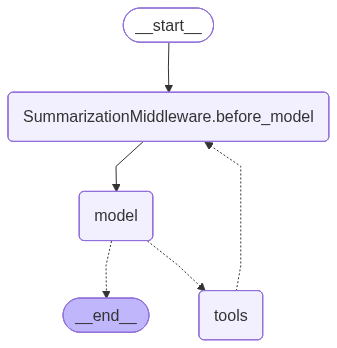

In [9]:
chatbot

# 도우미 함수 가져오기

In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

# 실행

In [10]:
import uuid
from langchain.messages import HumanMessage
from utils import extract_text

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

config = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

history = []
while True:
    user_message = input('\n>>> ')  
    if user_message.strip().lower() in ('quit', 'q', 'exit', '종료'):  
        print('감사합니다. 대화를 종료합니다. ')
        break
    result = chatbot.invoke(
        {'messages': [HumanMessage(user_message)]},
        config=config
    )
    print(extract_text(result['messages'][-1]))
    history.append(result)

반갑습니다, 고객님! 😊 종료하려면 'q' 또는 ‘종료’를 입력하세요.

오늘 드실 맛있는 한식 메뉴, 무엇을 도와드릴까요? 🍚🍲🍜 
오늘 주문 가능한 메뉴는 다음과 같습니다.

[메인 메뉴]
- 불고기 15,000원
- 비빔밥 10,000원
- 김치찌개 8,000원
- 해물파전 12,000원
- 잡채 9,000원

[추가 옵션]
- 계란 1,000원
- 두부 1,500원
- 고기 3,000원
- 해산물 4,000원
- 고추장 500원
- 김치 1,000원

[음료]
- 막걸리 3,000원
- 소주 4,000원
- 맥주 5,000원
- 생수 2,000원





>>>  안녕하세요. 저의 이름은 온톨로지입니다. 오늘의 추천 메뉴가 무엇인가요? 


어떤 메뉴를 주문하시겠어요? 원하시는 음식과 옵션을 알려주시면 확인해드릴게요.



>>>  저의 이름이 뭐였는지 알려줄 수 있나요?


고객님의 이름은 온톨로지님입니다. 어떤 메뉴를 주문하시겠어요?


...

매장 픽업을 선택하셨네요. 결제 방법을 알려주세요.

- 현금
- 신용카드
- 모바일 결제

원하시는 결제 방식을 알려주시면 주문을 마무리하겠습니다.



>>>  현금


감사합니다, 온톨로지님!  

**주문 내역**  
- 비빔밥: 10,000원  
- 계란 추가: 1,000원  
- 고추장 추가: 500원  
- 생수: 2,000원  

**총 금액:** 13,500원  

**결제 방식:** 현금  

주문이 완료되었습니다. 매장에 오시면 현금으로 결제해 주세요.  
맛있게 드시고, 좋은 하루 보내세요!



>>>  종료


감사합니다. 대화를 종료합니다. 


In [11]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
Confirm and finalize the user's order of bibimbap with egg, gochujang, and bottled water, providing a complete price breakdown and obtaining final confirmation.

## SUMMARY
- User’s name: 온톨로지  
- Finalized order items:
  1. 비빔밥 (Bibimbap) – 10,000원  
  2. 계란 추가 (Egg) – 1,000원  
  3. 고추장 추가 (Gochujang) – 500원  
  4. 생수 (Bottled water) – 2,000원  
- Total cost: 13,500원  
- User has confirmed the order with the response “확정합니다.”

## ARTIFACTS
None

## NEXT STEPS
None – the order has been confirmed and no further actions are required at this time.
================================== Ai Message ==================================

주문이 확정되었습니다.

**주문 내역**
- 비빔밥: 10,000원
- 계란 추가: 1,000원
- 고추장 추가: 500원
- 생수: 2,000원
**총 합계:** 13,500원

다음 중 어떤 방법으로 받으실까요?

1) 매장 픽업  
2) 배달  

선택해 주시면 결제 방법(현금, 신용카드, 모바일)도 알려드리겠습니다.
================================ Huma

In [12]:
for h in history:
    h['messages'][-1].pretty_print()

================================== Ai Message ==================================

어떤 메뉴를 주문하시겠어요? 원하시는 음식과 옵션을 알려주시면 확인해드릴게요.
================================== Ai Message ==================================

고객님의 이름은 온톨로지님입니다. 어떤 메뉴를 주문하시겠어요?
================================== Ai Message ==================================

주문 확인해드릴게요.

- 비빔밥: 10,000원  
- 계란 추가: 1,000원  
- 고추장 추가: 500원  

총 합계: **11,500원**입니다.

다른 메뉴를 추가로 주문하시겠어요? 아니면 이대로 최종 주문 확정하시겠어요?
================================== Ai Message ==================================

주문에 **생수**를 추가했습니다.

**주문 내역**
- 비빔밥: 10,000원  
- 계란 추가: 1,000원  
- 고추장 추가: 500원  
- 생수: 2,000원  

**총 합계:** 13,500원

이대로 최종 주문을 확정하시겠어요? 아니면 더 추가하거나 변경하실 내용이 있나요?
================================== Ai Message ==================================

주문이 확정되었습니다.

**주문 내역**
- 비빔밥: 10,000원
- 계란 추가: 1,000원
- 고추장 추가: 500원
- 생수: 2,000원
**총 합계:** 13,500원

다음 중 어떤 방법으로 받으실까요?

1) 매장 픽업  
2) 배달  

선택해 주시면 결제 방법(현금, 신용카드, 모바일)도 알려드리겠습니다.
================================

In [13]:
from langchain_core.messages import HumanMessage

print('=== Summarization Middleware 실행 로그 =======')
for turn_idx, h in enumerate(history, start=1):
    for msg in h['messages']:
        if (
            isinstance(msg, HumanMessage)
            and msg.additional_kwargs.get('lc_source') == 'summarization'
        ):
            print(f'\n[turn {turn_idx}] 요약 실행 감지')
            print(msg.content) 
            print('-' * 55)

=== Summarization Middleware 실행 로그 =======

[turn 3] 요약 실행 감지
Here is a summary of the conversation to date:

## SESSION INTENT
The user wants to know today’s recommended menu and also wants the assistant to recall and tell them their name.

## SUMMARY
- User introduced themselves as “온톨로지”.
- User initially asked for today’s recommended menu.
- Assistant asked for clarification on menu preferences.
- User then asked the assistant to tell them what their name is.

## ARTIFACTS
None

## NEXT STEPS
1. Respond with the user’s name (“온톨로지”) as requested.  
2. Provide a recommendation for today’s menu, optionally asking follow‑up questions to narrow preferences if needed.
-------------------------------------------------------

[turn 4] 요약 실행 감지
Here is a summary of the conversation to date:

## SESSION INTENT
The user wants the assistant to recall their name and provide today’s menu recommendation. They have now specified they would like bibimbap with egg and gochujang.

## SUMMARY
- User 

# Lab: 주문 완료 메시지 이중 생성 

- - -
**목표**
- `INSTRUCTION` 시스템 프롬프트를 수정하여, 에이전트가 주문이 최종 완료되는 시점에 **점주용 운영 메시지**와 **고객용 안내 메시지**를 각각 직접 생성하도록 만든다.
- 동시에 `SummarizationMiddleware`의 요약 시점 파라미터를 조정하여 에이전트가 긴 대화에서도 핵심 정보를 정확하게 유지하도록 한다.


**요구사항**
1. `INSTRUCTION`을 수정하여, 결제 방식 확인 후 주문이 완료되는 시점에 아래 두 가지 메시지를 **별도 섹션**으로 출력하도록 지시한다.
   - **[점주용 메시지]**: 주문 항목, 수량, 조리 우선순위, 픽업/배달 여부, 결제 수단을 포함한 간결한 운영 요약
   - **[고객용 메시지]**: 주문 확인 감사 인사, 주문 목록, 총 금액, 픽업/배달 안내 등 고객이 읽기 좋은 문구
2. `SummarizationMiddleware`의 파라미터를 `trigger=('messages', 4)`, `keep=('messages', 2)`로 변경한다.
3. 수정한 에이전트로 주문 완료까지 실제 대화를 진행하고, 점주용·고객용 메시지가 모두 출력되는 결과를 노트북에 남긴다.



**최소 테스트 질문**

다음 시나리오를 반드시 대화에 포함한다.

1. **'비빔밥 1개 주문할게요'** (메뉴 확인 및 주문 접수)
2. **'배달로 해주세요, 서울시 낙성구 얼음골 빙판로 11'** (배달 정보 입력)
3. **'카드로 결제할게요'** (결제 방식 선택 → 주문 완료 트리거)


**제출 안내**        
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.


<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- `INSTRUCTION` 안에 '결제가 완료되면 다음 두 섹션을 출력하라: [점주용 메시지], [고객용 메시지]'와 같이 **출력 형식을 구체적으로 명시**할수록 LLM이 원하는 형태로 생성한다.
- `trigger=('messages', 4)`는 대화가 **4**개 메시지에 도달하면 요약을 실행하라는 뜻이다. 숫자를 줄이면 더 이른 시점에 요약이 발생한다.
- `keep=('messages', 2)`는 요약 후 가장 최근 **2**개 메시지는 원문으로 유지하라는 뜻이다. 숫자를 줄이면 요약이 더 많은 비중을 차지한다.
- 점주용 메시지에는 실제 조리·운영에 필요한 정보(수량, 옵션, 배달 주소 등)를 중심으로 구성하고, 고객용 메시지는 친근하고 읽기 쉬운 문체로 작성하도록 프롬프트에 명시한다.

</details>

- - -

In [15]:
# YOUR CODE HERE

반갑습니다, 고객님! 😊 종료하려면 'q' 또는 ‘종료’를 입력하세요.

오늘 드실 맛있는 한식 메뉴, 무엇을 도와드릴까요? 🍚🍲🍜 
오늘 주문 가능한 메뉴는 다음과 같습니다.

[메인 메뉴]
- 불고기 15,000원
- 비빔밥 10,000원
- 김치찌개 8,000원
- 해물파전 12,000원
- 잡채 9,000원

[추가 옵션]
- 계란 1,000원
- 두부 1,500원
- 고기 3,000원
- 해산물 4,000원
- 고추장 500원
- 김치 1,000원

[음료]
- 막걸리 3,000원
- 소주 4,000원
- 맥주 5,000원
- 생수 2,000원





>>>  안녕하세요. 저의 이름은 온톨로지입니다. 오늘의 추천 메뉴가 무엇인가요? 


오늘은 비빔밥에 고추장 추가를 드시면 가볍게 즐기시기 좋을 것 같습니다. 어떤 메뉴와 옵션을 주문하시겠어요?



>>>  비빔밥에 계란과 고추장을 추가할게요.


고객님, 주문을 확인해드릴게요.

주문 내역:
- 비빔밥 1개 (10,000원)
- 계란 추가 1개 (1,000원)
- 고추장 추가 1개 (500원)

총 금액: 11,500원

추가로 주문하시고 싶은 사이드, 음료, 혹은 다른 옵션이 있으신가요? 필요하시면 알려주세요.


...

결제 방식은 현금, 신용카드, 모바일 중 어떤 것으로 진행하시겠어요?



>>>  카드로 할게요


--- [점주용 메시지] ---
주문: 비빔밥 1개, 계란 추가, 고추장 추가, 생수 1병 / 배달 / 서울시 낙성구 얼음골 빙판로 11 / 카드 결제 / 총액 13,500원

--- [고객용 메시지] ---
감사합니다! 비빔밥 1개(10,000원) + 계란 추가(1,000원) + 고추장 추가(500원) + 생수 1병(2,000원) = 13,500원 으로 주문이 완료되었습니다.  
배달 주소: 서울시 낙성구 얼음골 빙판로 11 로 보내드릴게요. 예상 배달 시간은 약 30~40분 정도입니다.  
카드 결제로 진행해 주셔서 감사합니다. 맛있게 드세요!



>>>  종료


감사합니다. 대화를 종료합니다. 


In [16]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
Finalize the user’s food order (bibimbap with extra egg and extra gochujang, plus bottled water) for delivery, and provide the final total, payment instructions, and delivery details.

## SUMMARY
- Order items confirmed:
  - 비빔밥 1개 – 10,000 원  
  - 계란 추가 – 1,000 원  
  - 고추장 추가 – 500 원  
  - 생수 1병 – 2,000 원  
- Total cost: 13,500 원.  
- Delivery method selected (“배달”).  
- Delivery address provided: 서울시 낙성구 얼음골 빙판로 11.

## ARTIFACTS
None.

## NEXT STEPS
1. Provide an estimated delivery time.  
2. Supply payment instructions (accepted methods and how to complete payment).  
3. If an ordering system is integrated, place the order for delivery.  
4. Send a final receipt confirming the total of 13,500 원.
================================== Ai Message ==================================

결제 방식은 현금, 신용카드, 모바일 중 어떤 것으로 진행하시겠어요?
======================

In [19]:
for h in history_v2:
    h['messages'][-1].pretty_print()

================================== Ai Message ==================================

오늘은 비빔밥에 고추장 추가를 드시면 가볍게 즐기시기 좋을 것 같습니다. 어떤 메뉴와 옵션을 주문하시겠어요?
================================== Ai Message ==================================

고객님, 주문을 확인해드릴게요.

주문 내역:
- 비빔밥 1개 (10,000원)
- 계란 추가 1개 (1,000원)
- 고추장 추가 1개 (500원)

총 금액: 11,500원

추가로 주문하시고 싶은 사이드, 음료, 혹은 다른 옵션이 있으신가요? 필요하시면 알려주세요.
================================== Ai Message ==================================

현재 주문 내역을 정리해 드릴게요.

- 비빔밥 1개 10,000원  
- 계란 추가 1,000원  
- 고추장 추가 500원  
- 생수 1병 2,000원  

총합: 13,500원

다른 사이드나 음료, 혹은 추가로 원하시는 것이 있으신가요? 추가하실 것이 없으시면 최종 확인을 진행하겠습니다.
================================== Ai Message ==================================

주문을 최종 확인합니다.

- 비빔밥 1개 10,000원  
- 계란 추가 1,000원  
- 고추장 추가 500원  
- 생수 1병 2,000원  

총 금액: 13,500원

픽업하시겠습니까, 아니면 배달을 원하시나요?
================================== Ai Message ==================================

배달 주소를 알려주시겠어요?
================================== Ai Message =======================

In [20]:
from langchain_core.messages import HumanMessage

print('=== Summarization Middleware 실행 로그 =======')
for turn_idx, h in enumerate(history_v2, start=1):
    for msg in h['messages']:
        if (
            isinstance(msg, HumanMessage)
            and msg.additional_kwargs.get('lc_source') == 'summarization'
        ):
            print(f'\n[turn {turn_idx}] 요약 실행 감지')
            print(msg.content) 
            print('-' * 55)

=== Summarization Middleware 실행 로그 =======

[turn 2] 요약 실행 감지
Here is a summary of the conversation to date:

## SESSION INTENT
Provide a recommended menu item for the user (온톨로지) and finalize their order choice.

## SUMMARY
- User (온톨로지) asked for today’s recommended menu.
- Assistant queried the menu tool and received the full list of dishes, sides, and beverages.
- Assistant suggested bibimbap with added gochujang as a light, tasty option.
- User accepted the suggestion and specified they want bibimbap with an egg and extra gochujang.

## ARTIFACTS
None.

## NEXT STEPS
- Confirm the user's order: bibimbap + egg + extra gochujang.
- Ask if the user would like any additional sides, drinks, or modifications.
- Once confirmed, proceed to place the order (or provide next steps for ordering).
-------------------------------------------------------

[turn 3] 요약 실행 감지
Here is a summary of the conversation to date:

## SESSION INTENT
Finalize the user’s food order based on the recommendation

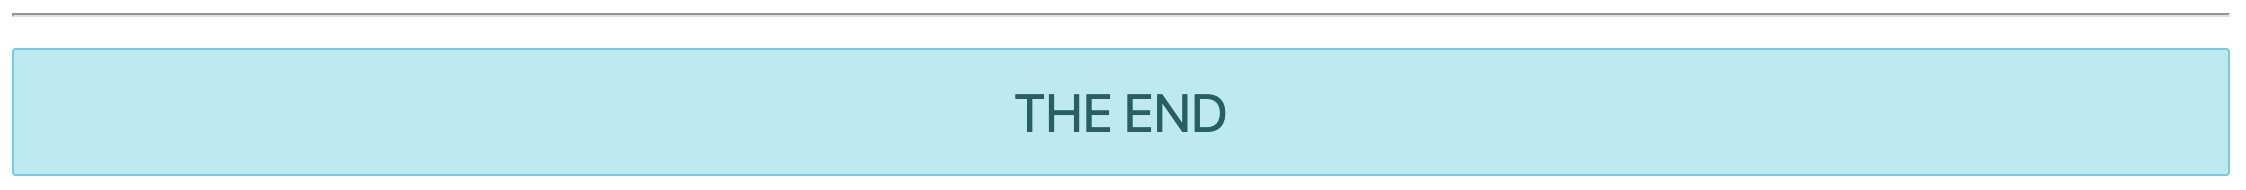